# This notebook computes pipe sizes based on extreme rainfall
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [47]:
#import libraries
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from scipy.optimize import fsolve
import pandas as pd
import numpy as np
import pymc3 as pm3
import scipy.stats as stats
from scipy import stats
from scipy.stats import genextreme
from scipy.stats import norm, gaussian_kde
from scipy.optimize import minimize
import seaborn as sns
import arviz as az
import pymc3 as pm
import os
import theano.tensor as tt
from theano.compile.ops import as_op
import theano
import pandas as pd
from pymc3.distributions.dist_math import bound
from scipy.stats import genextreme
import warnings
from arviz.plots import plot_utils as azpu
import arviz as az
from tqdm import tqdm
%matplotlib inline
sns.set()
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', UserWarning)
theano.config.warn.round=False
from watermark import watermark
from datetime import datetime
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import math
from dataclasses import dataclass
import re
from pathlib import Path

# Read the data

In [48]:
# --- Paths ---
BASE_DIR = r"D:\BMM-IDF4Drainage_data_results\Data\AORC"
CITIES_CSV = r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv"

# --- Load city list ---
cities_df = pd.read_csv(CITIES_CSV)
city_names = cities_df["City"].astype(str).str.strip().tolist()

# --- Final container ---
dataframes = {}

# --- Helper to read a CSV safely ---
def read_if_exists(path, usecols=None):
    if os.path.exists(path):
        return pd.read_csv(path, usecols=usecols)
    return None

# --- Build combined structure ---
for city_full in city_names:
    # Strip the state to get short name
    city_short = city_full.split(",")[0].strip()

    # Paths to the hourly and daily data
    hourly_path = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_hourly.csv")
    daily_path  = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_daily.csv")

    df_hourly = read_if_exists(hourly_path, usecols=["year", "max_hourly_mm"])
    df_daily  = read_if_exists(daily_path,  usecols=["year", "max_daily_mm"])

    if df_hourly is not None and df_daily is not None:
        # Keep only the common years between both
        df = pd.merge(df_hourly, df_daily, on="year", how="inner")

        # Rename columns to match your original structure
        df.rename(columns={"max_hourly_mm": "1h", "max_daily_mm": "24h"}, inplace=True)

        # Filter to 1979–2024 (if desired)
        df = df[df["year"].between(1979, 2024)]

        # Sort by year and reset index
        df = df.sort_values("year").reset_index(drop=True)

        # Save to dict with short name
        dataframes[city_short] = df

# --- print ---
print(dataframes["Birmingham"].head())
print(dataframes["Phoenix"])
print(list(dataframes.keys()))
# cities names
cities = ['Birmingham', 'Phoenix', 'Little Rock', 'Los Angeles', 'Denver', 'Hartford', 'Wilmington', 'Miami', 'Atlanta', 'Boise',
           'Chicago', 'Indianapolis', 'Des Moines', 'Wichita', 'Louisville', 'New Orleans', 'Portland', 'Baltimore', 'Boston', 'Detroit',
             'Minneapolis', 'Jackson', 'St. Louis', 'Billings', 'Omaha', 'Las Vegas', 'Manchester', 'Newark', 'Albuquerque', 'New York City',
               'Charlotte', 'Fargo', 'Columbus', 'Oklahoma City', 'Philadelphia', 'Providence', 'Charleston', 'Sioux Falls', 'Nashville', 'Houston',
                 'Salt Lake City', 'Burlington', 'Richmond', 'Seattle', 'Milwaukee', 'Cheyenne']             



   year         1h         24h
0  1979  21.200000  135.500002
1  1980  18.300000  102.500002
2  1981  43.200001   77.800001
3  1982  35.500001   74.100001
4  1983  24.100000  103.300002
    year         1h        24h
0   1979   8.400000  31.300000
1   1980   3.500000  14.100000
2   1981   4.600000  22.600000
3   1982   6.800000  24.700000
4   1983   9.700000  40.700001
5   1984   8.400000  32.300000
6   1985  10.400000  27.200000
7   1986   5.700000  28.900000
8   1987  15.000000  34.300001
9   1988   4.700000  26.100000
10  1989  20.400000  29.400000
11  1990   7.900000  29.400000
12  1991  20.200000  25.200000
13  1992  13.500000  42.400001
14  1993   7.700000  35.000001
15  1994  10.800000  15.300000
16  1995   6.800000  21.200000
17  1996   5.900000  11.300000
18  1997  11.300000  17.600000
19  1998   9.500000  18.200000
20  1999  11.900000  26.600000
21  2000   8.300000  51.100001
22  2001   6.000000  16.800000
23  2002   7.200000  13.700000
24  2003  16.100000  32.700000
25  2004

# **Asumptions:**
$$ 𝑄 = 0. 00278 𝐶𝐼𝐴 $$


Q is the peak discharge  (m^3/s)

C is the dimensionless runoff coefficient (C=0.65)  

I is the rainfall intensity (rainfall depths/duration) in mm/h 


A is taken as 10 acres for the 1-hour event and 40 acres for the 24-hour event.  

---

$$ 𝑄 = \frac{0.31} {n} D^{8/3} S^{0.5} $$

n is the Manning roughness coefficient,n= 0.013 for ordinary concrete lining  

s =0.005  

D is the pipe diameter in (mm). The resulting diameters are rounded off to the nearest US pipe sizes: 450, 525, 600, 675, 750, 900, and 1050 mm.

In [5]:
def pipe_sizing(depth, duration):
    """
    Calculates the required pipe diameter (D) given rainfall depth and duration
    using the Rational Method and Manning's formula.

    Parameters
    ----------
    depth : float
        Rainfall depth (mm)
    duration : float
        Duration (hr)
    """

    # rainfall intensity (mm/hr)
    I = depth / duration

    # drainage area (ha)
    if duration == 1:
        A = 10
    elif duration == 24:
        A = 40
    else:
        raise ValueError("Duration must be either 1 or 24 hours.")

    # discharge (m³/s)
    C = 0.65
    Q = 0.00278 * C * I * A

    # define Manning's and solve for D with S = 0.005, n = 0.013 initial guess 0.6 m 
    n = 0.013
    S = 0.005

    def func(D):
        return (0.31 / n) * D ** (8/3) * S ** 0.5 - Q

    D_initial = 0.6
    D_solution = fsolve(func, D_initial)[0]
    
    # Round up to nearest standard pipe size (mm)
    standard_sizes = np.array([450, 525, 600, 675, 750, 900, 1050,1200, 1350, 1500])  # mm
    D_mm = D_solution * 1000  # to mm
    D_rounded = standard_sizes[standard_sizes >= D_mm].min(initial=standard_sizes[-1])

    return  int(D_rounded)



In [49]:
D = pipe_sizing(depth=200.5, duration=24, )
print(f"Required pipe diameter: {D} mm")


Required pipe diameter: 1800 mm


In [85]:
# --- File paths ---
# Bayesian
b_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_Bayesian.csv'
b_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_Bayes.csv'
# MLE
mle_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_mle_AORC.csv'
mle_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_mle_AORC.csv'
# MOM
mom_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv'
mom_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_MOM.csv'
# rain_type
rain_path=r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_cities.csv"


# --- Load data ---
df_b_1h   = pd.read_csv(b_1h)
df_b_24h  = pd.read_csv(b_24h)
df_mle_1h = pd.read_csv(mle_1h)
df_mle_24h= pd.read_csv(mle_24h)
df_mom_1h = pd.read_csv(mom_1h)
df_mom_24h= pd.read_csv(mom_24h)
raintype=pd.read_csv(rain_path)


import pandas as pd
import numpy as np

def _normalize_citykey(s: pd.Series) -> pd.Series:
    # "New York, New York" -> "NEW YORK"
    return (
        s.astype(str)
         .str.split(",", n=1).str[0]
         .str.strip()
         .str.upper()
    )

def compute_pipe_column(df, duration, label, raintype_df, city_col="City", depth_col="50",
                        default_type="II", debug=True, debug_n=10):

    out = df[[city_col, depth_col]].copy()
    out["CityKey"] = _normalize_citykey(out[city_col])

    rt = raintype_df.copy()

    # Accept either CityKey or City in the rain-type file, but standardize to CityKey_norm
    if "CityKey" in rt.columns:
        rt["CityKey_norm"] = _normalize_citykey(rt["CityKey"])
    elif "City" in rt.columns:
        rt["CityKey_norm"] = _normalize_citykey(rt["City"])
    else:
        raise ValueError("raintype_df must have either a 'CityKey' column or a 'City' column.")

    if "rain_type" not in rt.columns:
        raise ValueError("raintype_df must have a 'rain_type' column.")

    # Ensure one row per city key in rain-type table
    rt = rt.drop_duplicates(subset=["CityKey_norm"], keep="first")

    # Merge with validation (will error if duplicates cause many-to-many)
    out = out.merge(
        rt[["CityKey_norm", "rain_type"]],
        left_on="CityKey",
        right_on="CityKey_norm",
        how="left",
        validate="many_to_one"
    )

    # Diagnostics: what didn't match?
    if debug:
        missing = out.loc[out["rain_type"].isna(), [city_col, "CityKey"]].drop_duplicates()
        print(f"[{label} | {duration}h] matched rain_type for "
              f"{out['rain_type'].notna().mean():.1%} of rows.")
        if len(missing) > 0:
            print(f"[{label} | {duration}h] Missing rain_type for {len(missing)} cities. Examples:")
            print(missing.head(debug_n).to_string(index=False))
        print(f"[{label} | {duration}h] rain_type counts (incl missing):")
        print(out["rain_type"].fillna("MISSING").value_counts())

    # Fill default if missing
    out["rain_type"] = out["rain_type"].fillna(default_type)

    # Compute pipe size row-by-row so you can trust rt is paired with the same row
    sizes = []
    for city, d, rtval in zip(out[city_col].values, out[depth_col].values, out["rain_type"].values):
        if pd.isna(d):
            sizes.append(np.nan)
        else:
            # If you want to confirm rt is changing, uncomment:
            # print(f"{label} {duration}h | {city} -> rt={rtval}")
            sizes.append(pipe_sizing(d, duration, raintype=rtval))
    out[label] = sizes

    return out[[city_col, label]]

# Build outputs (AORC)
pipe_sizes_1h = (
    compute_pipe_column(df_b_1h,   1,  "Bayesian", raintype)
    .merge(compute_pipe_column(df_mle_1h, 1, "MLE", raintype), on="City", how="outer")
    .merge(compute_pipe_column(df_mom_1h, 1, "MOM", raintype), on="City", how="outer")
    .reset_index(drop=True)
)
pipe_sizes_1h.to_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_1_hr.csv", index=False)

pipe_sizes_24h = (
    compute_pipe_column(df_b_24h,   24, "Bayesian", raintype)
    .merge(compute_pipe_column(df_mle_24h, 24, "MLE", raintype), on="City", how="outer")
    .merge(compute_pipe_column(df_mom_24h, 24, "MOM", raintype), on="City", how="outer")
    .reset_index(drop=True)
)
pipe_sizes_24h.to_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv", index=False)



[Bayesian | 1h] matched rain_type for 100.0% of rows.
[Bayesian | 1h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MLE | 1h] matched rain_type for 100.0% of rows.
[MLE | 1h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MOM | 1h] matched rain_type for 100.0% of rows.
[MOM | 1h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[Bayesian | 24h] matched rain_type for 100.0% of rows.
[Bayesian | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MLE | 24h] matched rain_type for 100.0% of rows.
[MLE | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MOM | 24h] matched rain_type for 100.0% of rows.
[MOM | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I     

# CMIP6

In [86]:
# --- Projected file paths ---
# MOM
p_mom_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_CMIP6_585_2065_2100_MOM.csv'

# MLE
p_mle_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_mle_CMIP6_585_2065_2100.csv'

# Bayesian
p_b_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_CMIP6_Bayes_585_2065_2100.csv'

# Rain type
rian_type= r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_cities.csv"


# --- Load projected data ---
df_p_mom_24h = pd.read_csv(p_mom_24h)
df_p_mle_24h = pd.read_csv(p_mle_24h)
df_p_b_24h   = pd.read_csv(p_b_24h)
raintype= pd.read_csv(rian_type)

import pandas as pd
import numpy as np

def _normalize_citykey(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.split(",", n=1).str[0]
         .str.strip()
         .str.upper()
    )

def compute_pipe_column_cmip(df, duration, label, raintype_df,
                             city_col="City", depth_col="50",
                             default_type="II", debug=True, debug_n=10):

    out = df[[city_col, depth_col]].copy()
    out["CityKey"] = _normalize_citykey(out[city_col])

    rt = raintype_df.copy()
    if "CityKey" in rt.columns:
        rt["CityKey_norm"] = _normalize_citykey(rt["CityKey"])
    elif "City" in rt.columns:
        rt["CityKey_norm"] = _normalize_citykey(rt["City"])
    else:
        raise ValueError("raintype_df must have either 'CityKey' or 'City'.")

    if "rain_type" not in rt.columns:
        raise ValueError("raintype_df must have a 'rain_type' column.")

    rt = rt.drop_duplicates(subset=["CityKey_norm"], keep="first")

    out = out.merge(
        rt[["CityKey_norm", "rain_type"]],
        left_on="CityKey",
        right_on="CityKey_norm",
        how="left",
        validate="many_to_one"
    )

    if debug:
        missing = out.loc[out["rain_type"].isna(), [city_col, "CityKey"]].drop_duplicates()
        print(f"[{label} | {duration}h] matched rain_type for "
              f"{out['rain_type'].notna().mean():.1%} of rows.")
        if len(missing) > 0:
            print(f"[{label} | {duration}h] Missing rain_type for {len(missing)} cities. Examples:")
            print(missing.head(debug_n).to_string(index=False))
        print(f"[{label} | {duration}h] rain_type counts (incl missing):")
        print(out["rain_type"].fillna("MISSING").value_counts())

    out["rain_type"] = out["rain_type"].fillna(default_type)

    sizes = []
    for city, d, rtval in zip(out[city_col].values, out[depth_col].values, out["rain_type"].values):
        if pd.isna(d):
            sizes.append(np.nan)
        else:
            # Uncomment for spot-checking:
            # print(f"[{label}] {city} -> rt={rtval}, depth={d}")
            sizes.append(pipe_sizing(d, duration, raintype=rtval))
    out[label] = sizes

    return out[[city_col, label]]

# --- Build projected 24-hour DataFrame ---
pipe_sizes_proj_24h = (
    compute_pipe_column_cmip(df_p_b_24h,    24, "Bayesian", raintype, debug=True)
    .merge(compute_pipe_column_cmip(df_p_mle_24h, 24, "MLE",     raintype, debug=True), on="City", how="outer")
    .merge(compute_pipe_column_cmip(df_p_mom_24h, 24, "MOM",     raintype, debug=True), on="City", how="outer")
    .reset_index(drop=True)
)

pipe_sizes_proj_24h.to_csv(
    r"D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv",
    index=False
)


[Bayesian | 24h] matched rain_type for 100.0% of rows.
[Bayesian | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MLE | 24h] matched rain_type for 100.0% of rows.
[MLE | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64
[MOM | 24h] matched rain_type for 100.0% of rows.
[MOM | 24h] rain_type counts (incl missing):
rain_type
II     40
III     4
I       1
IA      1
Name: count, dtype: int64


In [52]:
print("=== Pipe sizes for 1-hr (mm) ===")
print(pipe_sizes_proj_24h.describe())


=== Pipe sizes for 1-hr (mm) ===
          Bayesian          MLE          MOM
count    46.000000    46.000000    46.000000
mean   1117.391304  1266.304348  1294.565217
std     571.082538   295.532354   264.202839
min     250.000000   750.000000   750.000000
25%     900.000000  1050.000000  1150.000000
50%    1300.000000  1300.000000  1300.000000
75%    1500.000000  1300.000000  1450.000000
max    2500.000000  2300.000000  2000.000000


In [77]:
print("\n=== Pipe sizes for 24-hr (mm) ===")
print(pipe_sizes_proj_24h.head(50))


=== Pipe sizes for 24-hr (mm) ===
             City  Bayesian   MLE   MOM
0      Birmingham      1500  1300  1300
1         Phoenix      1150  1050  1150
2     Little Rock      2000  2000  1800
3     Los Angeles      1300  1150  1300
4          Denver      1150  1050  1150
5        Hartford      1150  1150  1150
6      Wilmington      1500  1300  1500
7           Miami      2500  2300  2000
8         Atlanta      1150  1150  1150
9           Boise       750   750   750
10        Chicago      1300  1300  1300
11   Indianapolis      1300  1300  1300
12     Des Moines      1500  1300  1300
13        Wichita      1300  1150  1300
14     Louisville      1150  1150  1300
15    New Orleans      2000  1800  1800
16       Portland      1300  1300  1300
17       Portland      1300  1300  1300
18       Portland      1300  1300  1300
19       Portland      1300  1300  1300
20       Portland      1300  1300  1300
21       Portland      1300  1300  1300
22       Portland      1300  1300  1300
23   

# NRCS method

CN=85 (moderately urbanized watershed.)
basin slope=1% (0.001-0.1) ref:https://wildlandhydrology.com/resources/docs/River%20Restoration%20and%20Natural%20Channel%20Design/Rosgen_2011_Natural_Channel_Design.pdf?utm_source=chatgpt.com
L = 4.499 A^0.466 (Re-evaluation of the Relationship of Master Streams and Drainage Basins) fpr 24 hr
hacks law L = 1.4 A^ O.6 for small 1hr 

In [7]:
#   Tc_hr = ( (L_ft^0.8) * ((1000/CN) - 10 + 1)^0.7 ) / (1140 * sqrt(S))
#
# Common interpretation for this equation family:
#   - L_ft is length in feet (we convert from meters)
#   - S is basin slope in PERCENT (1.0 means 1%, not 0.01)
#   - Tc is in hours

FT_PER_M = 3.28084
M_PER_MILE = 1609.344
SQMI_TO_KM2 = 2.589988110336


def tc_hours_from_length(L_m: float, CN: float, slope_percent: float,
                         denom: float = 1140.0) -> float:
    """Forward Tc calculation (hours) given L (meters), CN, and slope (percent)."""
    if CN <= 0 or CN >= 100:
        raise ValueError("CN should be between 0 and 100 (exclusive).")
    if slope_percent <= 0:
        raise ValueError("slope_percent must be > 0. Use 1.0 for 1%, not 0.01.")
    if L_m <= 0:
        raise ValueError("L_m must be > 0.")

    L_ft = L_m * FT_PER_M
    cn_term = ((1000.0 / CN) - 10.0 + 1.0) ** 0.7  # matches your expression (-10+1)
    return ( (L_ft ** 0.8) * cn_term ) / (denom * math.sqrt(slope_percent))


def length_from_tc_hours(tc_hr: float, CN: float, slope_percent: float,
                         denom: float = 1140.0) -> float:
    """Invert the Tc equation to compute L (meters) for a target Tc (hours)."""
    if tc_hr <= 0:
        raise ValueError("tc_hr must be > 0.")
    if CN <= 0 or CN >= 100:
        raise ValueError("CN should be between 0 and 100 (exclusive).")
    if slope_percent <= 0:
        raise ValueError("slope_percent must be > 0. Use 1.0 for 1%, not 0.01.")

    cn_term = ((1000.0 / CN) - 10.0 + 1.0) ** 0.7
    L_ft = ((tc_hr * denom * math.sqrt(slope_percent)) / cn_term) ** (1.0 / 0.8)
    return L_ft / FT_PER_M


# -----------------------------
# 2) Length–area relations
# -----------------------------
# Hack-style: L = c * A^h  (commonly c≈1.4, h≈0.6; region dependent)
def hack_area_from_length(L_m: float, c: float = 1.4, h: float = 0.6) -> tuple[float, float]:
    """Area from Hack-type relation. L in meters -> miles; returns A in sqmi and km2."""
    if L_m <= 0:
        raise ValueError("L_m must be > 0.")
    L_miles = L_m / M_PER_MILE
    A_sqmi = (L_miles / c) ** (1.0 / h)
    return A_sqmi, A_sqmi * SQMI_TO_KM2


# Mueller (1972): L = 4.499 * A^0.466  (L miles, A sq miles)
def mueller_area_from_length(L_m: float, c: float = 4.499, b: float = 0.466) -> tuple[float, float]:
    """Area from Mueller's general equation. L in meters -> miles; returns A in sqmi and km2."""
    if L_m <= 0:
        raise ValueError("L_m must be > 0.")
    if c <= 0 or b <= 0:
        raise ValueError("c and b must be > 0.")

    L_miles = L_m / M_PER_MILE
    A_sqmi = (L_miles / c) ** (1.0 / b)
    return A_sqmi, A_sqmi * SQMI_TO_KM2


# -----------------------------
# 3) Estimation wrapper
# -----------------------------
@dataclass
class BasinEstimate:
    tc_hr: float
    L_m: float
    L_km: float
    area_model: str
    A_sqmi: float
    A_km2: float


def estimate_basin_from_tc(tc_hr: float, CN: float, slope_percent: float,
                           area_model: str = "hack") -> BasinEstimate:
    """
    Step 1: Tc -> L (using your CN-based equation)
    Step 2: L -> A (using chosen length-area model)
      - area_model="hack"
      - area_model="mueller"
    """
    L_m = length_from_tc_hours(tc_hr=tc_hr, CN=CN, slope_percent=slope_percent)

    model = area_model.lower()
    if model == "hack":
        A_sqmi, A_km2 = hack_area_from_length(L_m)
    elif model == "mueller":
        A_sqmi, A_km2 = mueller_area_from_length(L_m)
    else:
        raise ValueError("area_model must be 'hack' or 'mueller'.")

    return BasinEstimate(
        tc_hr=tc_hr,
        L_m=L_m,
        L_km=L_m / 1000.0,
        area_model=model,
        A_sqmi=A_sqmi,
        A_km2=A_km2
    )


if __name__ == "__main__":
    CN = 85
    slope_percent = 1.0  # 1.0 means 1%

    # Use Mueller for 24 hr, Hack for 1 hr (as you requested)
    est_24 = estimate_basin_from_tc(tc_hr=24.0, CN=CN, slope_percent=slope_percent, area_model="mueller")
    est_1  = estimate_basin_from_tc(tc_hr=1.0,  CN=CN, slope_percent=slope_percent, area_model="hack")

    for est in (est_24, est_1):
        L_miles = est.L_m / M_PER_MILE
        print(f"\nTarget Tc = {est.tc_hr:.2f} hr")
        print(f"  L ≈ {est.L_km:.3f} km  ({L_miles:.3f} miles)")
        print(f"  Area model: {est.area_model}")
        print(f"  A ≈ {est.A_km2:.3f} km² ({est.A_sqmi:.3f} mi²)")

    # Optional sanity check (plug back in):
    print(tc_hours_from_length(est_24.L_m, CN, slope_percent))
    print(tc_hours_from_length(est_1.L_m, CN, slope_percent))


Target Tc = 24.00 hr
  L ≈ 44.052 km  (27.373 miles)
  Area model: mueller
  A ≈ 124.777 km² (48.177 mi²)

Target Tc = 1.00 hr
  L ≈ 0.829 km  (0.515 miles)
  Area model: hack
  A ≈ 0.490 km² (0.189 mi²)
24.000000000000014
1.0000000000000004


# Tmeporal disturibution of the rain

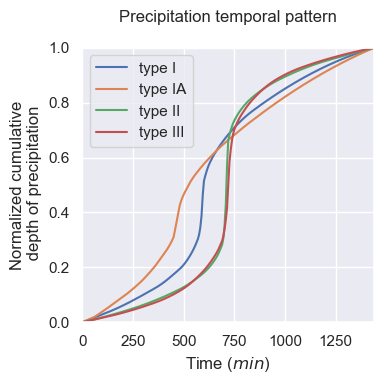

In [15]:
from pathlib import Path
from typing import Union
def load_hydrocad_hcr(path: Union[str, Path]):
    """
    Read a HydroCAD .hcr rainfall table and return:
      - time_min: np.ndarray of time (minutes) from 0..duration
      - cum_depth: np.ndarray of cumulative (mass-curve) depths (typically normalized 0..1)
      - duration_hr: total duration in hours
      - dt_min: inferred timestep (minutes)

    Notes:
    - HydroCAD .hcr files usually store cumulative depths on lines that start with 'depth='
    - duration/timeunits are read from the header.
    """
    path = Path(path)

    duration = None
    timeunits = None
    depths = []

    with path.open("r", errors="ignore") as f:
        for raw in f:
            line = raw.strip()

            if line.startswith("duration="):
                duration = float(line.split("=", 1)[1].strip())

            elif line.startswith("timeunits="):
                timeunits = line.split("=", 1)[1].strip().lower()

            elif line.startswith("depth="):
                nums = re.findall(
                    r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?",
                    line[len("depth="):]
                )
                depths.extend(float(x) for x in nums)

    if duration is None or timeunits is None:
        raise ValueError(f"Missing 'duration=' or 'timeunits=' in header: {path}")
    if len(depths) < 2:
        raise ValueError(f"No depth data found in: {path}")

    cum_depth = np.asarray(depths, dtype=float)

    # Convert duration to hours
    if timeunits in ("hour", "hours", "hr", "hrs"):
        duration_hr = duration
    elif timeunits in ("minute", "minutes", "min", "mins"):
        duration_hr = duration / 60.0
    else:
        raise ValueError(f"Unsupported timeunits='{timeunits}' in: {path}")

    # Infer dt from number of samples (assumes endpoints included)
    dt_hr = duration_hr / (cum_depth.size - 1)
    dt_min = dt_hr * 60.0

    time_min = np.arange(cum_depth.size) * dt_min
    return time_min, cum_depth, duration_hr, dt_min


def interp_to_common_time(time_min, cum_depth, common_time_min):
    """
    Interpolate cumulative depths to a common time grid for consistent plotting.
    """
    # Ensure strictly increasing time
    order = np.argsort(time_min)
    t = time_min[order]
    y = cum_depth[order]
    return np.interp(common_time_min, t, y)


# -----------------------------
# Paths to your 4 distributions
# -----------------------------
# If running locally, replace these with your local file paths.
file_I   = r"D:\repos\BMM-IDF4Drainage\Model\Temporal_dis_rainfall\\Type I 24-hr Tabular v2 (1).hcr"
file_IA  = r"D:\repos\BMM-IDF4Drainage\Model\Temporal_dis_rainfall\\Type IA 24-hr Tabular v2 (1).hcr"
file_II  = r"D:\repos\BMM-IDF4Drainage\Model\Temporal_dis_rainfall\\Type II 24-hr Tabular v2.hcr"
file_III = r"D:\repos\BMM-IDF4Drainage\Model\Temporal_dis_rainfall\\Type III 24-hr Tabular v2.hcr"

# -----------------------------
# Load all four
# -----------------------------
t_I,   depths_I,   dur_I,   dt_I   = load_hydrocad_hcr(file_I)
t_IA,  depths_IA,  dur_IA,  dt_IA  = load_hydrocad_hcr(file_IA)
t_II,  depths_II,  dur_II,  dt_II  = load_hydrocad_hcr(file_II)
t_III, depths_III, dur_III, dt_III = load_hydrocad_hcr(file_III)

# Sanity: require (approximately) the same total duration
durations = np.array([dur_I, dur_IA, dur_II, dur_III], dtype=float)
if np.max(np.abs(durations - durations[0])) > 1e-6:
    raise ValueError(f"Durations do not match: {durations} hours")

duration_hr = durations[0]

# Build a common time grid (use the smallest dt among the four)
dt_min_common = min(dt_I, dt_IA, dt_II, dt_III)
common_time = np.arange(0.0, duration_hr * 60.0 + 0.5 * dt_min_common, dt_min_common)

# Interpolate all curves to the same time axis (for clean overlay)
I_common   = interp_to_common_time(t_I,   depths_I,   common_time)
IA_common  = interp_to_common_time(t_IA,  depths_IA,  common_time)
II_common  = interp_to_common_time(t_II,  depths_II,  common_time)
III_common = interp_to_common_time(t_III, depths_III, common_time)

# If you want the arrays as plain Python lists like your example:
depths_I   = I_common.tolist()
depths_IA  = IA_common.tolist()
depths_II  = II_common.tolist()
depths_III = III_common.tolist()

# -----------------------------
# Plot all 4 distributions
# -----------------------------
plt.figure(figsize=(4, 4))
plt.plot(common_time, I_common,   label="type I",   linestyle="-")
plt.plot(common_time, IA_common,  label="type IA",  linestyle="-")
plt.plot(common_time, II_common,  label="type II",  linestyle="-")
plt.plot(common_time, III_common, label="type III", linestyle="-")

plt.xlabel("Time ($min$)")
plt.ylabel("Normalized cumulative\n depth of precipitation")
plt.xlim(0, duration_hr * 60)
plt.ylim(0, 1)
plt.title("Precipitation temporal pattern\n")
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()

# Save (edit to your preferred output path)
# plt.savefig(r"D:\culvert repo\Results\Figures\RainTypes_I_IA_II_III_temporal_pattern.png",
#             dpi=300, bbox_inches="tight")

plt.show()

For now model all by type II dis later digitize the map and get the pecise type.

In [16]:
def max_n_hr_rainfall(rain_type, interval_hours):
    """
    Finds the n-hour interval with the highest cumulative rainfall.
    Parameters:
    - depths_24hr (array-like): Cumulative depths for a 24-hour rainfall distribution.
    - total_hours (int): Total duration of the rainfall distribution, typically 24 hours.
    - interval_hours (int): Duration of the interval to find, typically 6 hours.
    Returns:
    - depths_6hr (np.array): Depths over the 6-hour interval with the highest rainfall.
    - start_time (float): Start time of the interval with the highest rainfall.
    """
   #############################################################     
    total_hours=24
    if rain_type=='II': 
        depths_24hr = np.array(depths_II)
    if rain_type=='III': 
        depths_24hr = np.array(depths_III)
    if rain_type=='I': 
        depths_24hr = np.array(depths_I)
    else:
        depths_24hr = np.array(depths_IA)
   #############################################################
    if interval_hours<0.5:
        # Time interval for original depths_II is 6 minutes, so generate time points
        time_6min = np.arange(0, len(depths_24hr) * 6, 6)
        
        # Interpolating depths for every 5 minutes
        interp_func = interp1d(time_6min, depths_24hr, kind='linear')
        time_5min = np.arange(0, time_6min[-1] + 1, 5)
        depths_24hr = interp_func(time_5min)
    #############################################################
    time_24hr = np.linspace(0, total_hours, len(depths_24hr))
    interval_steps = int(interval_hours * len(time_24hr) / total_hours)+2
    max_depth = 0
    start_index = 0
    for i in range(len(depths_24hr) - interval_steps):
        current_depth = depths_24hr[i + interval_steps] - depths_24hr[i]
        if current_depth > max_depth:
            max_depth = current_depth
            start_index = i
    depths_6hr = depths_24hr[start_index+1:start_index + interval_steps]
    depths_nhr= (depths_6hr - depths_6hr.min()) / (depths_6hr.max() - depths_6hr.min())
    start_time = time_24hr[start_index]
    return depths_nhr
# Call the function
#depth= max_n_hr_rainfall(rain_type='II',interval_hours=1)
#print("Depths in this interval:", depth)

In [17]:
def incremental_rainfall(cumulative_rainfall):
    """
    Calculate incremental rainfall from cumulative rainfall data.
    Parameters:
    - cumulative_rainfall (array-like): Array of cumulative rainfall depths.
    Returns:
    - incremental_rainfall (np.array): Array of incremental rainfall depths.
    """
    cumulative_rainfall = np.array(cumulative_rainfall)
    incremental_rain = np.diff(cumulative_rainfall, prepend=0)  # Set the first increment to the first cumulative depth
    return incremental_rain
# Example usage:
#incremental_rain = incremental_rainfall(depth)
#print("Incremental rainfall:", incremental_rain)


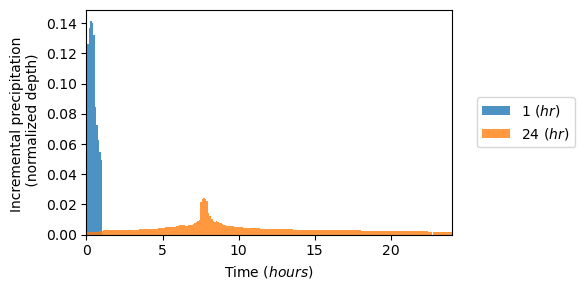

In [22]:
mpl.rcdefaults()
# Define intervals in hours
intervals = [1, 24]
# Store results
normalized_intervals = {}
# Compute and normalize rainfall for each interval
for interval in intervals:
    normalized_intervals[interval] = incremental_rainfall(
        max_n_hr_rainfall(rain_type='II', interval_hours=interval)
    )
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 3))  # Increase width to accommodate legend
# Plot each interval
for interval, depths in normalized_intervals.items():
    label = f"{int(interval * 60)} ($min$)" if interval < 1 else f"{interval} ($hr$)"
    ax.bar(np.linspace(0, interval, len(depths)), depths, width=interval/len(depths), label=label,alpha=0.8)
# Set labels and limits
ax.set_xlabel(f"Time ($hours$)")
ax.set_ylabel("Incremental precipitation \n (normalized depth)")
ax.set_xlim(0, 24)
# Move legend outside, right, and vertically centered
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
# Save the figure
#plt.savefig(r'D:\culvert repo\Results\Figures\normalized_temporal_incremental_rainfall_normalized_depths_typeII_ALL.png', 
#            dpi=300, bbox_inches='tight')
plt.show()

In [19]:
def calculate_excess_rainfall(rainfall_array, CN):
    # Curve number and initial abstraction calculations
    S = (25400 / CN) - 254
    I_default = 0.2 * S
    
    if len(rainfall_array)<6: 
        time_step=5 
    else: 
        time_step=6
    # Create a DataFrame with incremental depths (rainfall every 6 minutes)
    df = pd.DataFrame({
        'Time': np.arange(0, len(rainfall_array)*time_step, time_step),
        'Incremental Depths (mm)': rainfall_array
    })
    
    # Add the 'Cumulative Rainfall' column
    df['Cumulative Rainfall (mm)'] = df['Incremental Depths (mm)'].cumsum()
    
    # Calculate the 'Ia' (Initial Abstraction)
    df['Ia'] = df['Cumulative Rainfall (mm)'].apply(lambda P: min(P, I_default))
    
    # Calculate the 'Fa' (Fraction of Runoff) only when runoff occurs
    df['Fa'] = np.where(df['Cumulative Rainfall (mm)'] > df['Ia'],
                        (S * (df['Cumulative Rainfall (mm)'] - df['Ia'])) / 
                        (df['Cumulative Rainfall (mm)'] - df['Ia'] + S), 0) 
    
    # Calculate the 'Pe' (Excess Precipitation)
    df['Pe'] = np.maximum(df['Cumulative Rainfall (mm)'] - df['Ia'] - df['Fa'], 0)

    
    # Incremental Excess (difference in excess precipitation)
    df['Incremental Excess (mm)'] = df['Pe'].diff().fillna(df['Pe'])  # For the first value, just take 'Pe'
    
    return df

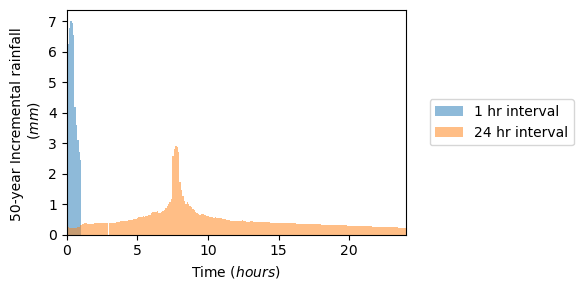

In [26]:
intervals = [1, 24]
depth = [
    1.95*2.54, 4.72*2.54
]
# Store results
normalized_intervals = {}
# Compute and normalize rainfall for each interval
for idx, interval in enumerate(intervals):
    rainfall = max_n_hr_rainfall(rain_type='II', interval_hours=interval) * depth[idx] * 10
    normalized_intervals[interval] = incremental_rainfall(rainfall)
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 3))  # Increase width to accommodate legend
# Plot each interval
for interval, depths in normalized_intervals.items():
    label = f"{int(interval * 60)} min interval" if interval < 1 else f"{interval} hr interval"
    ax.bar(np.linspace(0, interval, len(depths)), depths,width=interval/len(depths), label=label,alpha=0.5)
# Set labels and limits
ax.set_xlim(0, 24)
ax.set_xlabel(f"Time ($hours$)")
ax.set_ylabel(f"50-year Incremental rainfall \n ($mm$)")
# Move legend outside, right, and vertically centered
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
# Save the figure
#plt.savefig(r'D:\culvert repo\Results\Figures\temporal_incremental_rainfall_depths_culv_1_ALL.png', 
#            dpi=300, bbox_inches='tight')
plt.show()

In [23]:
def construct_unit_hydrograph(tc, A, tr, time_step):
    """
    Constructs a unit hydrograph based on the given parameters.
    
    Parameters:
    tc (float): Time of concentration (in hours).
    A (float): Catchment area (in square kilometers).
    tr (float): Duration of excessive rainfall (in hours, default is 0.1 hour or 6 minutes).
    
    Returns:
    tuple: Time intervals (hours), discharge values (m³/s) at each interval, and the plot.
    """
    # Calculate parameters
    tp = 0.6 * tc  # Time to peak
    Tp = (tr / 2) + tp  # Time to peak of the unit hydrograph
    qp = 0.208 * A / Tp  # Peak discharge (m³/s)
    base = 2.67 * Tp  # Duration of the unit hydrograph
    
    # Calculate the slope of the second line of the triangle
    slope_second = (0 - qp) / (base - Tp)
    
    # Define the 6-minute intervals (converted to hours)
    intervals_in_hours = np.arange(0, base, time_step / 60)  # Time in hours for 6-minute intervals
    
    # Initialize a list to store discharge values at 6-minute intervals
    discharge_values = []

    # Calculate discharge for the unit hydrograph at each 6-minute interval
    for t in intervals_in_hours:
        if t <= Tp:
            discharge_values.append((qp / Tp) * t)  # Linear increase until Tp
        else:
            discharge_values.append(qp + slope_second * (t - Tp))  # Linear decrease after Tp
    
    # Plot the unit hydrograph
    time = np.linspace(0, base, 100)
    discharge = np.zeros_like(time)

    for i, t in enumerate(time):
        if t <= Tp:
            discharge[i] = (qp / Tp) * t  # Linear increase until Tp
        else:
            discharge[i] = qp + slope_second * (t - Tp)  # Linear decrease after Tp
    return intervals_in_hours, discharge_values

# Example usage with your culvert data
#intervals, discharge_values = construct_unit_hydrograph(culvert.t_c_CN_wet[0], culvert.Area[0] / 10**6, 6 / 60, 6)


In [24]:
def calculate_total_discharge(df, unit_hydrograph):
    if len(df)<6:
        time_step=5
    else:
        time_step=6
    """
    Calculate the total discharge at each time step by applying the unit hydrograph
    to the incremental excess rainfall data.
    Parameters:
    df (pandas.DataFrame): DataFrame containing 'Time' and 'Incremental Excess (mm)' columns.
    unit_hydrograph (numpy.array): Array of unit hydrograph values for each time step.
    Returns:
    pandas.DataFrame: DataFrame with time steps, individual discharge values, and total discharge.
    """
    # Initialize a zero matrix for discharges, based on the number of time steps and unit hydrograph length
    discharge_matrix = np.zeros((len(df['Time']) + len(unit_hydrograph), len(df['Incremental Excess (mm)'])))
    # Loop through each Incremental Excess rainfall and calculate the discharge for each time step
    for idx, row in df.iterrows():
        # Multiply the Unit Hydrograph by the Incremental Excess value
        excess_rainfall = row['Incremental Excess (mm)']
        discharge_values = unit_hydrograph * excess_rainfall*(1/3.6)  # Multiply each Unit Hydrograph value by the Excess Rainfall
        # Find the start index where the rainfall begins (this corresponds to the current time step)
        start_idx = int(row['Time'] // time_step)  # Convert time step (in minutes) to the index (since it's a 6-minute interval)
        # Insert the discharge values starting from the corresponding time step
        discharge_matrix[start_idx:start_idx+len(unit_hydrograph), idx] = discharge_values
    # Create a DataFrame for the discharges
    discharge = pd.DataFrame(discharge_matrix, columns=[f'Discharge_{i+1}' for i in range(len(df['Incremental Excess (mm)']))])
    # Add the Time column to the DataFrame
    discharge['Time'] = np.concatenate([df['Time'], [df['Time'].iloc[-1] + time_step * (i+1) for i in range(len(unit_hydrograph))]])
    # Calculate the sum of discharges at each time step to get the total discharge
    discharge['Total Discharge'] = discharge.iloc[:, :-1].sum(axis=1)
    return discharge

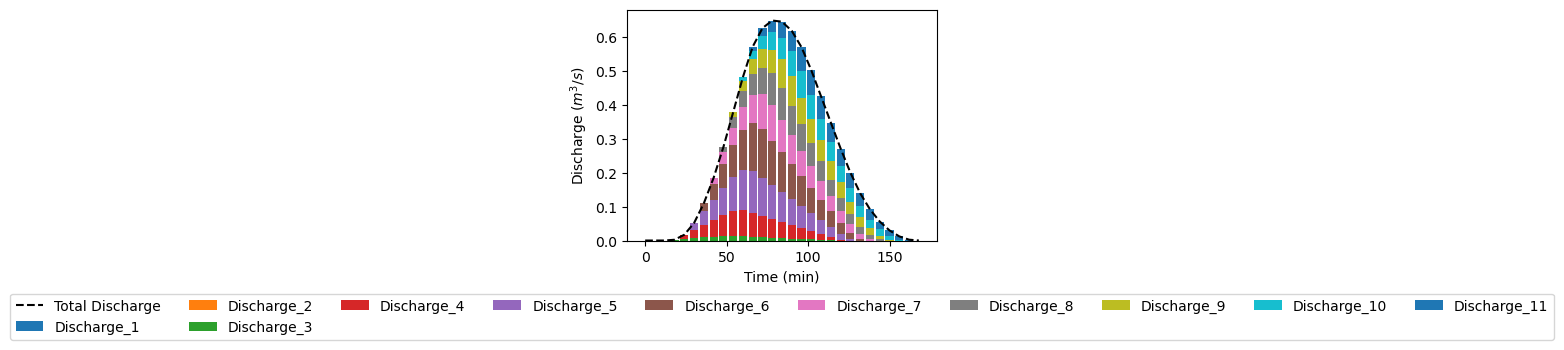

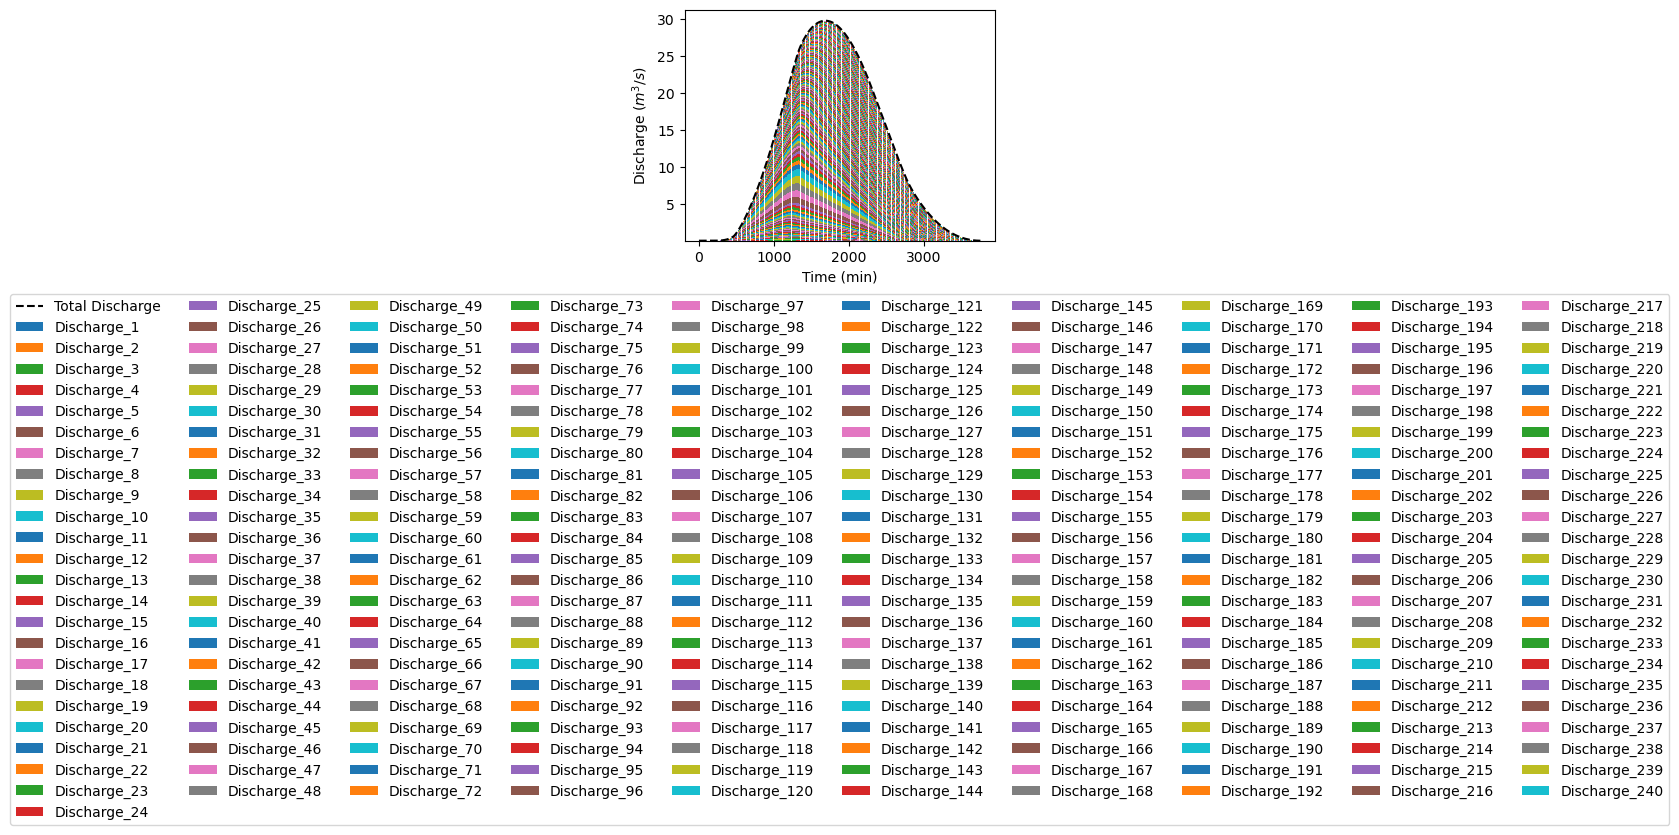

In [27]:
# List of intervals
intervals = [ 1, 24]
return_period=[2,5,10,25,50,100]
max_dis=0
# Loop through each interval
for interval in intervals:
    # Example rainfall data for each interval (replace with actual data)
    incremental_depths_new = normalized_intervals[interval]
    # Calculate the excess rainfall for each interval
    result_df = calculate_excess_rainfall(incremental_depths_new,CN=85)
    # Correct way to select columns from the result_df DataFrame
    data = result_df[['Time', 'Incremental Excess (mm)']]
    df = pd.DataFrame(data)
    #print(result_df)
    # Example Unit Hydrograph values (replace with your actual unit hydrograph values)
    time_step=6
    if interval==1:
        Area=0.49
    else:        
        Area=124.777
    intervals_1, discharge_values = construct_unit_hydrograph(interval, Area,time_step/60,time_step)
    unit_hydrograph = np.array(discharge_values)  # Example unit hydrograph values
    # Calculate the total discharge for this interval
    discharge = calculate_total_discharge(df, unit_hydrograph)
    #print(len(df))
    # Ensure discharge is a DataFrame and get the 'Total Discharge' column
    total_discharge = discharge['Total Discharge']
    # Find the time of maximum discharge
    max_discharge_index = total_discharge.idxmax()
    max_discharge_row = discharge.iloc[max_discharge_index]
    #print(max_discharge_row)
    # Check if the third-to-last element is non-zero
    #if max_discharge_row[-3] != 0:
    max_dis = max_discharge_row[-1]
    # Plotting
    plt.figure(figsize=(4, 3))
    # Plot stacked bars for each discharge
    bottom_values = np.zeros(len(discharge))  # Start from zero for the first stack
    for col in discharge.columns[:-2]:  # Exclude Time and Total Discharge columns
        plt.bar(discharge['Time'], discharge[col], bottom=bottom_values, label=col, width=5)
        bottom_values += discharge[col]
    # Plot total discharge line
    plt.plot(discharge['Time'], discharge['Total Discharge'], color='black', linestyle='--', label='Total Discharge')
    # Add labels and title
    plt.xlabel('Time (min)')
    plt.ylabel('Discharge ($m^3/s$)')
    #plt.title(f'Stacked Contribution of Each Incremental Discharge to Total Discharge for Interval {interval} hrs')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=10)
    #plt.savefig(rf'D:\culvert repo\Results\Figures\UH\{interval}.png',bbox_inches='tight',dpi=300)
    # Show the plot for the current interval
    plt.show()
#print("Max Discharge:", max_dis)

# new pipesizing scheme

In [46]:
def pipe_sizing(depth, duration,CN=85, raintype='II'):
    """
    Calculates the required pipe diameter (D) given rainfall depth and duration
    using the Rational Method and Manning's formula.

    Parameters
    ----------
    depth : float
        Rainfall depth (mm)
    duration : float
        Duration (hr)
    """
    # Hydlologic dishcharge calculation (NRCS)
    interval=duration
    if interval==1:
        Area=0.49
    else:
        Area=124.777
    #
    rainfall = max_n_hr_rainfall(rain_type=raintype, interval_hours=interval) * depth
    normalized_intervals[interval]= incremental_rainfall(rainfall)
    # Calculate excess rainfall for each interval
    result_df = calculate_excess_rainfall(normalized_intervals[interval], CN=85)
    # Extract relevant data for discharge calculation
    df = result_df[['Time', 'Incremental Excess (mm)']]
    # Determine time step based on interval
    time_step = 6
    intervals_1, discharge_values = construct_unit_hydrograph(
                interval, Area, time_step / 60, time_step
            )
    unit_hydrograph = np.array(discharge_values)
    # Calculate total discharge for this interval
    discharge = calculate_total_discharge(df, unit_hydrograph)
    # Get the total discharge column
    total_discharge = discharge['Total Discharge']
    # Find the maximum discharge value for the current interval
    max_discharge_index = total_discharge.idxmax()
    max_discharge_row = discharge.iloc[max_discharge_index]
    Q = max_discharge_row[-1]
    if interval == 24:
        Q = Q * 0.1 # 10 pips are requried
    #hydraulic calculations

    # define Manning's and solve for D with S = 0.005, n = 0.013 initial guess 0.6 m 
    n = 0.013
    S = 0.005

    def func(D):
        return (0.31 / n) * D ** (8/3) * S ** 0.5 - Q

    D_initial = 0.6
    D_solution = fsolve(func, D_initial)[0]
    
    # Round up to nearest standard pipe size (mm)
    standard_sizes = np.array([250,350, 450, 525, 600, 675, 750, 900, 1050, 1150, 1300, 1500, 1800, 2000, 2300, 2500, 2700])  # mm
    D_mm = D_solution * 1000  # to mm
    D_rounded = standard_sizes[standard_sizes >= D_mm].min(initial=standard_sizes[-1])

    return  int(D_rounded)

#pipe_sizing(depth=1.95*2.54*10, duration=1, CN=85, raintype='II')
#pipe_sizing(depth=4.72*2.54*10, duration=24, CN=85, raintype='II')


In [8]:
#Getting the current date and time
current_datetime = datetime.now()

# Printing the date and time
print("Date and Time of the Notebook Analysis:", current_datetime)

Date and Time of the Notebook Analysis: 2025-11-16 16:44:10.232023


In [9]:
%load_ext watermark

# Print the Python version and some dependencies
%watermark -v -m -p numpy,pandas,matplotlib,pymc3,scipy,seaborn,arviz,os,theano,warnings,tqdm,watermark


Python implementation: CPython
Python version       : 3.9.19
IPython version      : 8.18.1

numpy     : 1.22.1
pandas    : 2.0.3
matplotlib: 3.8.4
pymc3     : 3.11.6
scipy     : 1.7.3
seaborn   : 0.13.2
arviz     : 0.12.1
os        : unknown
theano    : 1.1.2
warnings  : unknown
tqdm      : 4.66.4
watermark : 2.4.3

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 24
Architecture: 64bit

